# Whipper Trebuchet Simulation

This notebook demonstrates a whipper-style trebuchet.
A whipper trebuchet features a hinged counterweight system, but with the counterweight hanger positioned at the top of the throwing arm. 
When cocked, the arm points forward in the direction of the throw. At the start, the weight and projectile 'rest' on the trebuchet arm.

What you’ll see here:
- Build a default whipper configuration (`Trebuchet.default_whipper()`)
- Solve the multi-phase motion for the whipper mechanism
- Report key timing and range metrics
- Animate the launch sequence

> Tip: For clearer visuals, tweak `skip` (frame thinning) and `delay` (milliseconds per frame) in the animation cell.


In [1]:
import sys

sys.path.insert(0, "../src")
from pytrebuchet import Projectile, Simulation, SimulationPhases, Trebuchet

## 1. Setup & Solve

We create a whipper `Trebuchet` and a default `Projectile`, then call `Simulation.solve()` to integrate the equations of motion through the whipper-specific phases:

- Both constrained: arm, whipper, and projectile move kinematically linked
- Projectile constrained: projectile remains constrained while the whip transitions
- Sling unconstrained: sling dynamics prior to release
- Ballistic: free-flight trajectory after release

Printed metrics include sling release time, ground impact time, and horizontal range.


In [2]:
trebuchet = Trebuchet.default_whipper()
projectile = Projectile.default()
simulation = Simulation(trebuchet, projectile)

simulation.solve()

# print(f"Ground separation time: {simulation.get_phase_end_time(SimulationPhases.GROUND_SLIDING):.4f} s")
print(
    f"Sling release time: {simulation.get_phase_end_time(SimulationPhases.SLING_UNCONSTRAINED):.4f} s"
)
print(
    f"Ground impact time: {simulation.get_phase_end_time(SimulationPhases.BALLISTIC):.4f} s"
)
print(f"Horizontal range: {simulation.distance_traveled:.2f} m")

Sling release time: 1.9464 s
Ground impact time: 8.8093 s
Horizontal range: 192.16 m


## 2. Animation

Below we animate the whipper launch sequence. Only the first frame will render on GitHub; run locally to view the full motion.

> Adjust parameters in `animate_launch(simulation, skip=10, delay=50)` for smoother or faster playback.


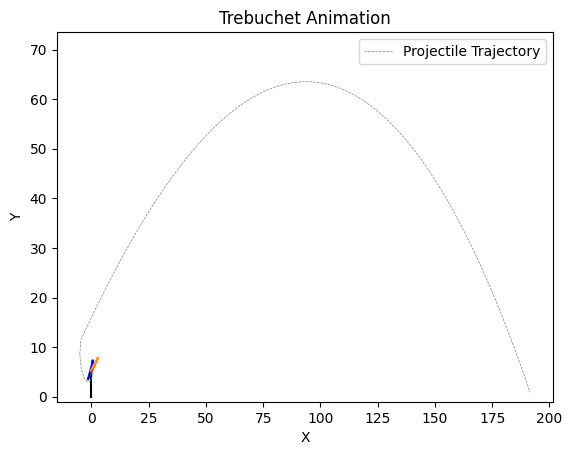

In [3]:
from pytrebuchet.plotting import animate_launch

animate_launch(simulation, skip=10, delay=50)